<a href="https://colab.research.google.com/github/AlHartMos/IEU_courses/blob/main/simulating_and_modeling/3_1_Monte_Carlo_Simulations_Excercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monte Carlo Simulation

## Introduction to Monte Carlo Simulation

The definition of the Monte Carlo concept can be a bit confusing. For this reason, we will take Sawilowsky’s example and distinguish between: Simulation, Monte Carlo method and Monte Carlo simulation.

* A **Simulation** is a fictitious representation of reality. For example: Drawing one pseudo-random uniform variable from the interval [0,1] can be used to simulate the tossing of a coin. If the value is less than or equal to 0.50 designate the outcome as heads, but if the value is greater than 0.50 designate the outcome as tails. This is a simulation, but not a Monte Carlo simulation.
* A **Monte Carlo method** is a technique that can be used to solve a mathematical or statistical problem. For example: Pouring out a box of coins on a table, and then computing the ratio of coins that land heads versus tails is a Monte Carlo method of determining the behavior of repeated coin tosses, but it is not a simulation.
* A **Monte Carlo simulation** uses repeated sampling to obtain the statistical properties of some phenomenon (or behavior). For example: drawing a large number of pseudo-random uniform variables from the interval [0,1] at one time, or once at many different times, and assigning values less than or equal to 0.50 as heads and greater than 0.50 as tails, is a Monte Carlo simulation of the behavior of repeatedly tossing a coin.

The main idea of this method is that a phenomenon is simulated multiple times on a computer by generating random numbers and the results are aggregated to provide statistical summaries associated with the phenomenon. Sawilowsky lists the characteristics of a high-quality Monte Carlo simulation:

* The (pseudo-random) number generator has certain characteristics (e.g. a long “period” before the sequence repeats)
* The (pseudo-random) number generator produces values that pass tests for randomness
* There are enough samples to ensure accurate results
* The algorithm used is valid for what is being modeled
* It simulates the phenomenon in question

## Steps in a Monte Carlo Simulation

Monte Carlo methods vary, but tend to follow a particular pattern:
1. Define a domain of possible inputs
2. Generate inputs randomly from a probability distribution over the domain
3. Perform a deterministic computation on the inputs
4. Aggregate the results

Let us do a classic Monte Carlo Simulation experiment, the π number estimation.


## The $\pi$ number estimation

$\pi$ is the mathematical constant, which is equal to $3.14159265…$, defined as the ratio of a circle’s circumference to its diameter:

$$
\pi = \dfrac{C}{d}
$$

The number $π$ appears in many formulas across mathematics and physics. It is an irrational number, meaning that it cannot be expressed exactly as a ratio of two integers, although fractions such as $\tfrac{22}{7}$ are commonly used to approximate it. Consequently, its decimal representation never ends, nor enters a permanently repeating pattern. It is a transcendental number, meaning that it cannot be a solution of an equation involving only sums, products, powers, and integers.

The invention of calculus soon led to the calculation of hundreds of digits of π, enough for all practical scientific computations. Nevertheless, in the 20th and 21st centuries, mathematicians and computer scientists have pursued new approaches that, when combined with increasing computational power, extended the decimal representation of π to many trillions of digits. A very common computational way to calculate it is through Monte Carlo Simulation. Let's see some considerations for the experiment (figure below):

![img](https://drive.google.com/uc?id=14ErgZCgtAC_DWcn6q7Yg4F02uvM7a3er)

* Consider a circle with radius $r = 1$, which is fixed and known.
* Imagine that this circle is circumscribed within a square, which therefore has side 2r (also equal to the diameter).

**What is the probability that if I choose a random point inside the square, it will also be inside the circle?** If I choose any random point within the square, it can be inside the circle or just inside the square. A very simple way to compute this probability is the ratio between the area of the circle and the area of the square.

$$
P(\text{point inside the circle}) = \dfrac{\text{area of the circle}}{\text{area of the square}} = \dfrac{\pi r^2}{2r \cdot 2r} = \dfrac{\pi}{4}
$$

The probability that a randomly selected point in the square is in the circle is $\tfrac{\pi}{4}$. This means that if I were to replicate the selection of a random point in the square a large number of times, I could **count the proportion of points inside the circle, multiply it by four and that would give me an approximation of $\pi$.**

$$
\dfrac{\pi}{4} = \dfrac{\text{points in the circle}}{\text{total points}}
$$

$$
\pi = {4 \cdot \dfrac{\text{points in the circle}}{\text{total points}}}
$$

We will create a Monte Carlo experiment in Python which implements the ideas above.

1. Set the circle to be centered on (0,0) with radius ( r ) = 1, the domain of the inputs will be random numbers between -1 and 1
2. Generate pseudo-random numbers between -1 and 1 following  uniform distribution as an input.
3. Calculate the squared distance of the point (x,y) to the origin (0,0); $$x^2 + y^2$$

    If the value is less than 1 (radius squared), the point will be inside the circle

    If the value is greater than 1 (radius squared), the point will be outside the circle.
4. Calculate the proportion of points inside the circle and multiply it by 4
5. Replicate the experiment a many times to get different approximations for π.
6. Aggregate the previous experiments to give an average value estimate or range.

### Step 1-2: Define the domain and generate the random numbers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import math

In [2]:
np.random.seed(2025) #set a random seed

nPoints = 500 #set a number of points to generate
x = np.random.uniform(-1, 1, nPoints) #using np.uniform, generate n points from the range -1 to 1
y = np.random.uniform(-1, 1, nPoints) #using np.uniform, generate n points from the range -1 to 1

#check the values of x, return the first 9 values
print(x[0:9].round(3))
#check the values of y, return the first 9 values
print(y[0:9].round(3))

[-0.729  0.776  0.865 -0.109 -0.224 -0.485  0.315 -0.015  0.928]
[ 0.567 -0.483 -0.072 -0.181  0.284 -0.72  -0.155  0.695  0.624]


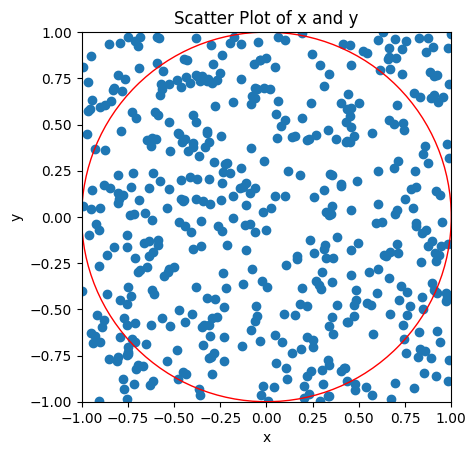

In [3]:
#create a scatter plot, use the values for x and y.
plt.scatter(x, y)
#this creates a circle object and overlays it on top of the graph created above
circle = plt.Circle((0, 0), 1, color='red', fill=False)
plt.gca().add_artist(circle)

#set the x and y limits of the graph from -1 to 1 using xlim and y lim
plt.xlim(-1, 1)
plt.ylim(-1, 1)

#dont worry-be happy, these are just additional QoL additions
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Scatter Plot of x and y")
plt.xlabel("x")
plt.ylabel("y")

#show the plot
plt.show()

### Calculate the distance
Calculate the squared distance of the point (x,y) to the origin (0,0); $$x^2 + y^2$$

    If the value is less than 1 (radius squared), the point will be inside the circle

    If the value is greater than 1 (radius squared), the point will be outside the circle.

In [4]:
#we now create a function called 'dist' to calculate the distance of each point to the center (0,0)

def dist(x,y):
  #create an empty array called 'result'
  result = []

  for i in range(len(x)):
    #calculate "point" =  x squared + y squared
    point = (x[i] ** 2) + (y[i] ** 2)
    #create an if-else statement. If point <= 1 then append "True" to the result array, else append "False"
    if (point <= 1):
      result.append(True)
    else:
      result.append(False)

  return(result)

sim_points = dist(x,y)
print(sim_points[0:10])

[True, True, True, True, True, True, True, True, False, True]


in this case, in the first 10 simulated points, 9 fall within the circle and 1 falls just in the square

###4. Calculate the proportion of points inside the circle and multiply it by 4 to estimate $π$

In [5]:
#calculate "pi_val" which is 4 times the proportion of points inside the circle
pi_val =  4 * (np.sum(sim_points) / nPoints) #remember the sum function treats True = 1 and False = 0
print(pi_val) #what is the value of pi_val?

3.072


So not exactly our know value for $π$ but what if we replicate this N times?

###5. Replicate the experiment a many times to get different approximations for π.

Lets first go back and encapsulate our number generation and calculations into a single function

In [6]:
#lets put all of the previous steps into 1 function

def pi_val_func(nPoint):
  x = np.random.uniform(-1,1,nPoint)
  y = np.random.uniform(-1,1,nPoint)
  values = []
  for i in range(len(x)):
    point = x[i]**2 + y[i]**2
    if(point<=1):
      values.append(True)
    else:
      values.append(False)
  pi_val = 4*sum(values)/nPoint
  return(pi_val)

In [7]:
np.random.seed(2025) #set a random seed to the same value as before

#use your new function from above to generate 500 points and return the value
print(pi_val_func(500))

3.072


Now we have that all in a function and we confirmed we got the same initial estimate (we set the seed for both). We can now replicate this function as many times as we want (100,1000,etc)

> Add blockquote



In [8]:
def replicate_pi(n_replicas, nPoint):
  #create an empty array to store the results of the replications. called "replicas"
  replicas = []
  for i in range(n_replicas):
    #append the results of the pi_val_function to replicas
    replicas.append(pi_val_func(nPoint))
  return(np.array(replicas))

In [10]:
np.random.seed(2025)
pi_numbers = replicate_pi(1_000, 500) #run replicate_pi multiple times
print(pi_numbers[0:10])

[3.072 3.192 3.208 3.216 3.256 3.088 3.264 3.048 3.144 3.016]


We now have a thousand estimates of $\pi$ lets proceed to aggregate and get the mean of the estimates
###6. Aggregate the previous experiments to give an average value estimate or range.

In [11]:
#get the mean of all the replicates, remember this is in "pi_numbers"
print(np.mean(pi_numbers))

3.135984


Another way to summarize the results is with the use of a box plot

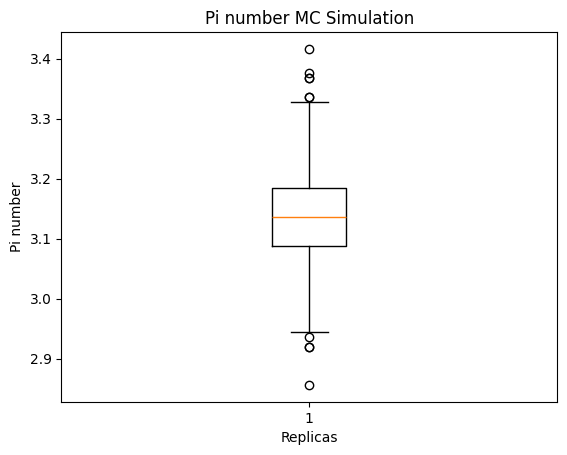

In [12]:
#create a boxplot of the replicas with plt
plt.boxplot(pi_numbers) # See the distriibution of pi values (means)
plt.xlabel("Replicas")
plt.ylabel("Pi number")
plt.title("Pi number MC Simulation")
plt.show()

The boxplot tells us two important things:
* if we were to take the average of the 1,000 approximations of π as the value of π, we would get a value very close to the actual value (see the horizontal line inside the box).
* if we were to choose a value for π based on a single simulation, then we could choose values between 2.8 and 3.5.

One thing you might wonder now is the following.
**Why did we replicate the experiment 1000 times and each time took only 500 points. Could have we not taken a much larger number of points only once (for example 1000×500)?**

On one hand that would have clearly given us a good approximation, using the same total number of simulated points.




In [13]:
np.random.seed(2025)


#Calculate the mean of replicate_pi if we asked it to run 1 replication but with many many many points
replicate_pi(1, 500_000_000).mean() # RAM crashes between 600_000_000 and 500_000_000

np.float64(3.141619408)

However this approach does not give us any information about uncertainty or about how good our approximation is. We have just one single value. On the other hand, using replication we have 1000 possible approximations of π and we can construct confidence intervals of plausible values. For instance, we would believe that the true value π  is with 95% probability in the interval which includes 95% of the central approximations of π.

### Additional Step: extending our knowledge

We can store the results of the experiment increasing the number of points and replicas to plot the optimization function of the $\pi$ number estimation.

In [15]:
def optim_func_pi(max_nPoints, max_Replicas, n_repetitions):

  nPoints_sequence = np.linspace(100,max_nPoints,n_repetitions).round(0)
  replicas_sequence = np.linspace(1000,max_Replicas,n_repetitions).round(0)
  pi_averages = []

  for i in range(n_repetitions):
    print("Starting the estimation ", i, " out of ", n_repetitions)
    pi_vector = replicate_pi(int(nPoints_sequence[i]), int(replicas_sequence[i]))
    pi_averages.append(pi_vector.mean())

  return(pi_averages)

In [ ]:
results = optim_func_pi(5000,10000,100) # do not run this line, takes a while

In [ ]:
results_arr = np.array(results)
plt.plot(results_arr, 'o-', label = 'Pi Values')
plt.legend()
plt.title('Pi Value Estimation using MC simulation')
plt.xlabel('Repetitions')
plt.ylabel('Pi Value Mean')
plt.show()

# The Choice Function

We have carried out our first Monte Carlo experiment. We will carry out others in the rest of this chapter and interpret their results. There is one function, the `choice` function which we will often use.

In the previous chapter we discussed how to simulate numbers distributed according to a specific random variable. One possible class of numbers we may want to simulate in some situations are integers. Suppose for example you want to simulate a dice game: then we must be able to simulate in Python a number of the set {1, 2, 3, 4, 5, 6} where each has the same probability of appearing.

For this specific purpose we have choice function. This takes four inputs:
* `a`: an array of values we want to sample from.
* `size`: the size of the sample we want.
* `replace`: if True sampling is done with replacement. That is if a value has been selected, it can be selected again. By default equal to False.
* `p`: an array of the same length of a giving the probabilities that the elements of a are selected. By default equal to a uniform probability.

So, for example, if we wanted to simulate ten tosses of a fair dice we can write:


In [16]:
np.random.seed(2025)
np.random.choice(a = np.arange(1,7), size = 10, replace = True)

array([3, 5, 1, 4, 4, 5, 1, 1, 6, 3])

The vector a does not have to be numeric. We could have a vector of characters instead. For example, lets simulate the red, black, and green tiles from a game of roulette. A standard european table has 18 red, 18 black, and 1 green tile.

In [19]:
np.random.seed(2025)
np.random.choice(a = ["red", "black", "green"], size = 10, replace = True, p=[18/37, 18/37, 1/37])

array(['red', 'black', 'black', 'red', 'red', 'red', 'black', 'black',
       'black', 'black'], dtype='<U5')

In [20]:
# Generate 6 unique integers from 1 to 49 inclusive, with replace = False
random_integers = np.random.choice(np.arange(1, 50), 6, False)
print(random_integers)

[45 30 25 39  2 40]


###A game of chance

Lets start simulating a little game of chance.

You and a friend play a game of rock-paper-scissors. In any one “match” the outcome can be you lose, you win, or you tie. If you lose you give 1 euro to your friend, if you win you gain 1 euro, and if you tie you both get nothing. Both of you start with 0 euros. Let’s simulate 50 games and see how lucky you are.

We can simulate this game using the Python choice() function. The domain of possible outcomes are {-1€, 0€ , 1€} all with equal probability. Your winnings on 50 repeated matches can be considered to be a sample of size 50 selected with replacement from the set {-1€, 0€ , 1€}.

In [21]:
np.random.seed(2025)
win = np.random.choice(a = [-1, 0, 1], size = 50, replace = True)
print(win[0:15])

[ 1  1  1  1 -1 -1 -1 -1  1 -1  0  1  1  0 -1]


In this particular game, you won the first 4 matches, lost the next 4 matches, etc...

Being the super competitive person you are, you are interested in knowing your cummulative winnings as you play the game. The function `np.cumsum()` computes the running total of the values and we can store these values in another vector we will call `cumul_win`

In [22]:
cumul_win = np.cumsum(win)
print(cumul_win[0:15])

[1 2 3 4 3 2 1 0 1 0 0 1 2 2 1]


Getting the final value of this `cumul_win` vector will give us the final result of your games. Alternatively, you can also just get the sum of the `win` vector

In [23]:
#show the last value of the cumul_win array
print(cumul_win[len(cumul_win) - 1])

-7


In [25]:
#use the sum function to get the sum of cumul_win
print(win.sum())

-7


So at the end of this particular game, you are down 7 euros. We can plot the evolution of the game with a line plot



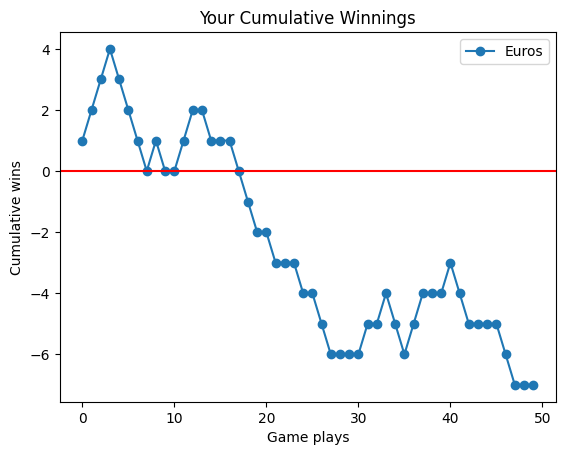

In [26]:
cumul_win = np.array(cumul_win)
#use plt.plot and create the plot object
plt.plot(cumul_win, 'o-', label = "Euros")
plt.legend()
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Your Cumulative Winnings')
plt.xlabel('Game plays')
plt.ylabel('Cumulative wins')
plt.show()

Of course this is the result of only 1 game and in another universe the results could be completely different (or if you just decided to play another 50 matches of rock-paper-scissors...)

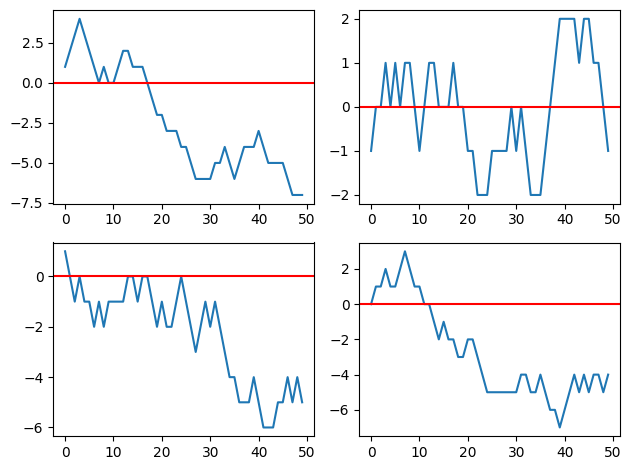

In [27]:
np.random.seed(2025)
fig, axs = plt.subplots(2, 2)

#not too important but the arguments axs[x,y] just tell plt where to place the graphs given the subplots argument above
cumul_win = np.array(np.cumsum(np.random.choice(a = [-1,0,1], size = 50, replace = True)))
axs[0, 0].plot(cumul_win, '-')
axs[0, 0].axhline(y=0, color='r', linestyle='-')

cumul_win = np.array(np.cumsum(np.random.choice(a = [-1,0,1], size = 50, replace = True)))
axs[1, 0].plot(cumul_win, '-')
axs[1, 0].axhline(y=0, color='r', linestyle='-')

cumul_win = np.array(np.cumsum(np.random.choice(a = [-1,0,1], size = 50, replace = True)))
axs[0, 1].plot(cumul_win, '-')
axs[0, 1].axhline(y=0, color='r', linestyle='-')

cumul_win = np.array(np.cumsum(np.random.choice(a = [-1,0,1], size = 50, replace = True)))
axs[1, 1].plot(cumul_win, '-')
axs[1, 1].axhline(y=0, color='r', linestyle='-')

fig.tight_layout()

Moral of the story is don't gamble....

That aside, suppose we are interested in the following question.

**What is the probability that you breakeven at the end of the game?**

Evidently we cannot cannot answer by simply looking at the outputs of the previous simulations. We need to do a formal Monte Carlo study. In this type of experiment, we simulate the random process and compute the statistic of interest. By repeating the random process many times, we obtain a collection of values of the statistic, which can then be used to approximate probabilities or expectations that answer the questions.

As you recall from the estimation of $π$ experiment, we first need to write a function that simulates the experiment. In particular we need to write a function which outputs your winnings at the end of the game. To make this function more general, we define `n` to be the number of matches and let the default value of `n` be 50.

In [ ]:
#create a function to simulate the experiment, allow the number of "matches" or "n" be a variable we set. call the function "rps"

In [29]:
np.random.seed(2025)
def rps(n = 50):
  return(sum(np.random.choice(a = [-1, 0, 1], size = n, replace = True)))

np.random.seed(2025)
print(rps())

np.int64(-7)

We have recreated the results of your first game so it seems our function works correctly.

Lets now replicate the experiment (the game) many times.

In [30]:
def rps_reps(replicas=1000,n=50):
  results = []
  for i in range(replicas):
    results.append(rps(n))
  return np.array(results)
  #create a function to run rps many times (ie to run "replicas"), create a variable for the results called "results"

In [33]:
np.random.seed(2025)
experiment = rps_reps()
#show the first 15 results of the experiment
print(experiment[:15])
print(experiment.sum())

[ -7  -5  -1  -4  -1   4  -4   3  -3   0   5   0   2 -11  -7]
-122


the result of each game (with 50 matches) is recorded in the experiment array. Since the results is an integer-value variable, it is convenient to summarize it using the table function.

In [32]:
experiment = pd.Series(sorted(experiment))
experiment_df = pd.DataFrame(experiment.value_counts(sort = False).rename_axis('final winnings').reset_index(name='number of games'))
experiment_df.T # Makes graph horizontal

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
final winnings,-19,-17,-16,-15,-14,-13,-12,-11,-10,-9,...,8,9,10,11,12,13,14,15,16,18
number of games,3,1,3,3,4,3,11,14,13,18,...,23,18,19,13,6,7,2,3,4,1


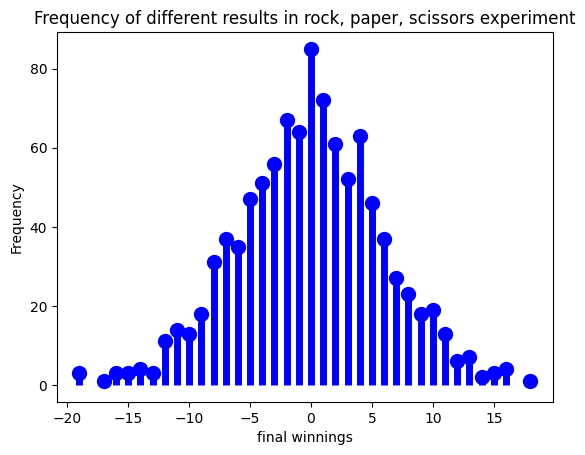

In [34]:
plt.vlines(experiment_df["final winnings"], 0, experiment_df["number of games"], colors='b', lw=5)
plt.plot(experiment_df["final winnings"], experiment_df["number of games"], 'bo', markersize=10)
plt.xlabel("final winnings")
plt.ylabel("Frequency")
plt.title("Frequency of different results in rock, paper, scissors experiment")
plt.show()

**What is the probability that you breakeven at the end of the game?**

So we can see that you breakeven in 85 games out of 1000 . Furthermore the plot shows us that most commonly You will win/lose little money and that big wins/losses are unlikely.

To conclude our experiment we need to calculate our estimated probability of you breaking even. Clearly this is equal to $85/1000= 0.085$. In Python:

In [39]:
#final answer here

print("Probability of breaking even: ", sum((experiment == 0)) / len(experiment) * 100)
print("Probability of winning: ", sum((experiment > 0)) / len(experiment) * 100)

Probability of breaking even:  8.5
Probability of winning:  45.4
